<h3>เป้าหมายที่ 4: สร้างหลักประกันว่าทุกคนมีการศึกษาที่มีคุณภาพอย่างครอบคลุมและเท่าเทียม และสนับสนุนโอกาสในการเรียนรู้ตลอดชีวิต </h3>

<h3>เป้าหมายที่ 10: ลดความไม่เสมอภาคภายในและระหว่างประเทศ</h3>

In [52]:
import torch
p = torch.cuda.get_device_properties(0)
print(p.name, p.major, p.minor)  # major=8, minor=7  -> 8.7


Orin 8 7


In [53]:
import mediapipe as mp, sys
print("mediapipe    :", mp.__version__)
# ไม่มี API ทางการบอก CUDA ตรงๆ ใน Python
# ทดสอบว่า Tasks delegate=GPU ใช้ได้ไหม (ส่วนใหญ่บน Jetson จะไม่รองรับ → error/fallback)
try:
    from mediapipe.tasks.python import BaseOptions
    print("Tasks module available. GPU delegate on Jetson is generally unsupported.")
except Exception as e:
    print("Tasks module not available or import error:", e)
print("Conclusion: MediaPipe pip wheel on Jetson = CPU-only (unless you custom-build).")


mediapipe    : 0.10.5
Tasks module available. GPU delegate on Jetson is generally unsupported.
Conclusion: MediaPipe pip wheel on Jetson = CPU-only (unless you custom-build).


In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp



In [ ]:
import sys, cv2
print("python =", sys.executable)
print("cv2   =", cv2.__file__)



<h2>Keypoint MP Holistic</h2>

In [2]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_face_mesh = mp.solutions.face_mesh

In [3]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [4]:
def draw_landmarks(image, results):
    # Face landmarks
    # if results.face_landmarks:
    #     mp_drawing.draw_landmarks(
    #         image, 
    #         results.face_landmarks, 
    #         mp_face_mesh.FACEMESH_CONTOURS  # แก้ไขเป็น FACEMESH_CONTOURS
    #     )

    # Pose landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS
        )
    
    # Left hand landmarks
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )

    # Right hand landmarks
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )


In [5]:
def draw_styled_landmarks(image, results):
    # mp_drawing.draw_landmarks(
    #         image, 
    #         results.face_landmarks, 
    #         mp_face_mesh.FACEMESH_CONTOURS ,
    #         mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
    #         mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
    #     )
    
    mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(80,22,10), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80,44,121), thickness=1, circle_radius=1)
            
        )
    
    mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(121,22,76), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(121,44,250), thickness=1, circle_radius=1)
        )
    
    mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245,117,66), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(245,66,2330), thickness=1, circle_radius=1)
        )

In [11]:
import cv2
import time

# เปิดกล้อง (0 = กล้องตัวแรก)
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0   # สำหรับคำนวณ FPS

with mp_holistic.Holistic(min_detection_confidence=0.75,
                          min_tracking_confidence=0.75) as holistic:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        h, w = frame.shape[:2]
        one_seventh = w // 6          # แบ่งจอเป็น 7 ส่วน
        x1, x2 = one_seventh * 1, one_seventh * 5   # ใช้ช่วง 2–5 (≈ 28%–71%)

        # --- ROI เฉพาะกลางจอ (ช่วง 2–5) ---
        roi = frame[:, x1:x2]
        roi_img, results = mediapipe_detection(roi, holistic)
        draw_styled_landmarks(roi_img, results)

        # วาง ROI กลับเข้าเฟรมเต็ม
        frame[:, x1:x2] = roi_img

        # คำนวณ FPS
        current_time = time.time()
        fps = 1 / (current_time - prev_time) if prev_time != 0 else 0
        prev_time = current_time

        # แสดง FPS บนเฟรม
        cv2.putText(frame, f'FPS: {int(fps)}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # เส้นกรอบช่วยบอกขอบเขตตรวจจับ
        cv2.rectangle(frame, (x1, 0), (x2-1, h-1), (0, 255, 255), 2)

        cv2.imshow('OpenCV Feed', frame)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


[ WARN:0@81.256] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


In [16]:

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0
mp_holistic = mp.solutions.holistic

with mp_holistic.Holistic(min_detection_confidence=0.5,
                          min_tracking_confidence=0.5) as holistic:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # ประมวลผลด้วย mediapipe
        image, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(frame, results)

        # คำนวณ FPS
        curr_time = time.time()
        fps = 0 if prev_time == 0 else 1 / (curr_time - prev_time)
        prev_time = curr_time

        # วางข้อความ FPS ที่มุมขวาบน
        h, w = frame.shape[:2]
        cv2.putText(frame, f'FPS: {int(fps)}',
                    (w - 150, 30),                      # ➡ ตำแหน่ง x,y
                    cv2.FONT_HERSHEY_SIMPLEX, 1,        # ➡ ฟอนต์และขนาด
                    (0, 255, 0), 2)                     # ➡ สีเขียว ขนาดเส้น 2

        # แสดงผลภาพ
        cv2.imshow('OpenCV Feed', frame)

        # ออกจากลูปเมื่อกด q
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0
mp_holistic = mp.solutions.holistic

with mp_holistic.Holistic(min_detection_confidence=0.75,
                          min_tracking_confidence=0.75) as holistic:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # ประมวลผลด้วย mediapipe
        image, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(frame, results)

        # คำนวณ FPS
        curr_time = time.time()
        fps = 0 if prev_time == 0 else 1 / (curr_time - prev_time)
        prev_time = curr_time

        # วางข้อความ FPS ที่มุมขวาบน
        h, w = frame.shape[:2]
        cv2.putText(frame, f'FPS: {int(fps)}',
                    (w - 150, 30),                      # ➡ ตำแหน่ง x,y
                    cv2.FONT_HERSHEY_SIMPLEX, 1,        # ➡ ฟอนต์และขนาด
                    (0, 255, 0), 2)                     # ➡ สีเขียว ขนาดเส้น 2

        # แสดงผลภาพ
        cv2.imshow('OpenCV Feed', frame)

        # ออกจากลูปเมื่อกด q
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

# ปิดกล้อง
cap.release()
cv2.destroyAllWindows()


[ WARN:0@1192.476] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1
[ WARN:0@4150.537] global cap_gstreamer.cpp:2829 handleMessage OpenCV | GStreamer warning: Embedded video playback halted; module v4l2src1 reported: Device '/dev/video0' is busy
[ WARN:0@4150.538] global cap_gstreamer.cpp:1698 open OpenCV | GStreamer warning: unable to start pipeline
[ WARN:0@4150.538] global cap_gstreamer.cpp:1173 isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
[ WARN:0@4150.538] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@4150.541] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


In [ ]:
len(results.left_hand_landmarks.landmark)

In [ ]:
results

In [ ]:
draw_styled_landmarks(frame, results)

In [ ]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

<h2>Extract Keypoint Values</h2>

In [ ]:
len(results.pose_landmarks.landmark)

In [ ]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [ ]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
# face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

<h3>extract_kp</h3>

In [6]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    # face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, lh, rh])

In [ ]:
result_test = extract_keypoints(results)

In [ ]:
result_test #468*3+33*4+21*3+21*3

<h2>Setup Folder for Collect data</h2>

In [ ]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect                                            
actions = np.array(['hello', 'thank','recommended' ,'today','speak'
                    , 'iced', 'hot'
                    , 'cocoa', 'green', 'thai' ,'tea' , 'americano', 'latte'
                    ])
                    # , 'americano', 'latte'
                    # , 'milk', 'black'
                    # , 'payAll'
fix_actions = ['thaitea']
# Thirty videos worth of data
no_sequences = 120

# Videos are going to be 30 frames in length
sequence_length = 25

In [8]:
# hello
## 0
## 1
## 2
## ...
## 29
# thanks

# I love you

In [8]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

<h2>Collect Keypoint Values for Training and Testing</h2>

In [20]:
target_actions = ['speak'] #, 'greentea', 'thaitea' , 'latte'

In [13]:
cap = cv2.VideoCapture(0,cv2.CAP_V4L2)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    # Loop through actions
    for action in target_actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)
#                 print(results)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

FileNotFoundError: [Errno 2] No such file or directory: 'MP_Data/hello/11/20.npy'

In [21]:
import cv2
import os
import numpy as np
import time
import mediapipe as mp

cap = cv2.VideoCapture(0, cv2.CAP_V4L2)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0    # สำหรับคำนวณ FPS

mp_holistic = mp.solutions.holistic

with mp_holistic.Holistic(min_detection_confidence=0.5,
                          min_tracking_confidence=0.5) as holistic:

    for action in target_actions:                 # วนคลาส
        for sequence in range(no_sequences):      # วนวิดีโอ
            for frame_num in range(sequence_length):   # วนเฟรม

                ret, frame = cap.read()
                if not ret:
                    break

                # ทำ detection
                image, results = mediapipe_detection(frame, holistic)
                draw_styled_landmarks(image, results)

                # ==== คำนวณ FPS ====
                curr_time = time.time()
                fps = 0 if prev_time == 0 else 1 / (curr_time - prev_time)
                prev_time = curr_time

                # ==== แสดง FPS ที่มุมขวาบน ====
                h, w = image.shape[:2]
                cv2.putText(image, f'FPS: {int(fps)}',
                            (w - 120, 30),               # ตำแหน่ง x,y
                            cv2.FONT_HERSHEY_SIMPLEX,    # ฟอนต์
                            0.8,                         # ขนาดตัวอักษร
                            (0, 255, 0), 2)              # สีเขียว

                # ==== ข้อความสำหรับการเก็บข้อมูล ====
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120, 200),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, f'Collecting frames for {action} Video {sequence}',
                                (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else:
                    cv2.putText(image, f'Collecting frames for {action} Video {sequence}',
                                (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)

                # ==== บันทึก keypoints ====
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break

cap.release()
cv2.destroyAllWindows()


In [11]:
cap.release()
cv2.destroyAllWindows()

<h2>6. Preprocess Data and Create Labels and Features</h2>

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [10]:
label_map = {label:num for num, label in enumerate(actions)}


In [11]:
label_map

{'hello': 0,
 'thank': 1,
 'recommended': 2,
 'today': 3,
 'iced': 4,
 'hot': 5,
 'cocoa': 6,
 'green': 7,
 'thai': 8,
 'tea': 9,
 'americano': 10,
 'latte': 11}

In [13]:
newno_sequences = 60
newsequence_length = 30

In [12]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [13]:
np.array(sequences).shape

(1440, 25, 258)

In [14]:

np.array(labels).shape

(1440,)

In [15]:
X = np.array(sequences)

In [16]:
X.shape

(1440, 25, 258)

In [17]:
y = to_categorical(labels).astype(int)

In [18]:
y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [20]:
y_train.shape

(1368, 12)

In [21]:
y_test.shape

(72, 12)

<h2>7. Build and Train LSTM Neural Network</h2>

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input,Dropout
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping

In [23]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [24]:
model = Sequential()
model.add(Input(shape=(25, 258)))
model.add(LSTM(64, return_sequences=True, activation='relu'))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(actions), activation='softmax'))

1970-01-01 08:56:56.901556: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
1970-01-01 08:56:56.964521: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
1970-01-01 08:56:56.964696: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
1970-01-01 08:56:56.969167: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
1970-01-01 08:56:56.969696: I external/local_xla/xla/stream_executor

In [25]:
res = [.7, 0.2, 0.1]

In [26]:
actions[np.argmax(res)]

'hello'

In [27]:
learning_rate = 3e-6

In [28]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=learning_rate)

In [29]:
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

earlystop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

model.fit(X_train, y_train, epochs=300, validation_split=0.2,
          callbacks=[tb_callback, earlystop, reduce_lr], batch_size=16,shuffle=True)

1970-01-01 08:57:22.093230: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28225200 exceeds 10% of free system memory.
1970-01-01 08:57:22.124305: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28225200 exceeds 10% of free system memory.


Epoch 1/300


I0000 00:00:7048.540351    4486 service.cc:145] XLA service 0xaaaae257c9d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:7048.540697    4486 service.cc:153]   StreamExecutor device (0): Orin, Compute Capability 8.7
1970-01-01 08:57:28.732968: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
1970-01-01 08:57:29.785592: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 90300
I0000 00:00:7055.558205    4486 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 213ms/step - categorical_accuracy: 0.0878 - loss: 2.4861 - val_categorical_accuracy: 0.0766 - val_loss: 2.4840 - learning_rate: 3.0000e-06
Epoch 2/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - categorical_accuracy: 0.0878 - loss: 2.4817 - val_categorical_accuracy: 0.0766 - val_loss: 2.4800 - learning_rate: 3.0000e-06
Epoch 3/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - categorical_accuracy: 0.0878 - loss: 2.4776 - val_categorical_accuracy: 0.0766 - val_loss: 2.4760 - learning_rate: 3.0000e-06
Epoch 4/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - categorical_accuracy: 0.0878 - loss: 2.4730 - val_categorical_accuracy: 0.0766 - val_loss: 2.4713 - learning_rate: 3.0000e-06
Epoch 5/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - categorical_accuracy: 0.0878 - loss: 2.4677 - val_categorical_accuracy: 0.0766 - val_loss: 2.4659 - learning_rate: 3.0000e-06
Epoch 6/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - categorical_accuracy: 0.0878 - loss: 2.4610 - val_catego

In [31]:
model.fit(X_train, y_train,
          epochs=300,                 # ใส่ epoch สูงสุดที่ต้องการ (เช่น 200)
          initial_epoch=112,          # บอกให้เริ่มนับต่อจาก epoch 101
          validation_split=0.2,
          callbacks=[tb_callback, earlystop, reduce_lr],
          batch_size=16,
          shuffle=True)


Epoch 113/300
 1/69 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - categorical_accuracy: 1.0000 - loss: 0.0573

1970-01-01 09:05:24.968909: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28225200 exceeds 10% of free system memory.
1970-01-01 09:05:25.002626: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28225200 exceeds 10% of free system memory.


69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - categorical_accuracy: 0.9634 - loss: 0.1229 - val_categorical_accuracy: 0.9526 - val_loss: 0.1613 - learning_rate: 9.3750e-08
Epoch 114/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - categorical_accuracy: 0.9644 - loss: 0.1228 - val_categorical_accuracy: 0.9562 - val_loss: 0.1633 - learning_rate: 9.3750e-08
Epoch 115/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - categorical_accuracy: 0.9644 - loss: 0.1225 - val_categorical_accuracy: 0.9562 - val_loss: 0.1655 - learning_rate: 9.3750e-08
Epoch 116/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - categorical_accuracy: 0.9653 - loss: 0.1223 - val_categorical_accuracy: 0.9526 - val_loss: 0.1674 - learning_rate: 9.3750e-08
Epoch 117/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - categorical_accuracy: 0.9653 - loss: 0.1223 - val_categorical_accuracy: 0.9526 - val_loss: 0.1690 - learning_rate: 9.3750e-08
Epoch 118/300
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - categorical_accuracy: 0.9653 - loss: 0.1221 - va

GRU

In [26]:
# Cell 1
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input, Dropout
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ถ้ายังไม่ได้กำหนด actions ให้กำหนดก่อนรันโมเดล เช่น:
# actions = ["hello","thank","recommended","today","hot","iced","thaitea","greentea","americano","latte","cocoa"]

log_dir = os.path.join("Logs")
tb_callback = TensorBoard(log_dir=log_dir)


In [31]:
# Cell 2
model = Sequential()

# input shape: (timesteps=25, features=258)
model.add(Input(shape=(25, 258)))

# 3 GRU layers (โครงแบบเดียวกับ LSTM เดิม)
model.add(GRU(64, return_sequences=True, activation='relu'))
model.add(GRU(128, return_sequences=True, activation='relu'))
model.add(GRU(64, return_sequences=False, activation='relu'))

# Dense heads
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output
model.add(Dense(len(actions), activation='softmax'))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 25, 64)         │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 25, 128)        │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,621 (705.55 KB)

 Trainable params: 180,621 (705.55 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Cell 3
learning_rate = 3e-6
optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)


In [33]:
# Cell 4
earlystop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = model.fit(
    X_train, y_train,
    epochs=400,
    validation_split=0.2,
    callbacks=[tb_callback, earlystop, reduce_lr],
    batch_size=16
)


Epoch 1/400
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - categorical_accuracy: 0.0371 - loss: 2.5654 - val_categorical_accuracy: 0.0673 - val_loss: 2.5647 - learning_rate: 3.0000e-06
Epoch 2/400
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - categorical_accuracy: 0.1359 - loss: 2.5615 - val_categorical_accuracy: 0.1549 - val_loss: 2.5606 - learning_rate: 3.0000e-06
Epoch 3/400
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - categorical_accuracy: 0.1418 - loss: 2.5572 - val_categorical_accuracy: 0.1549 - val_loss: 2.5566 - learning_rate: 3.0000e-06
Epoch 4/400
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - categorical_accuracy: 0.1916 - loss: 2.5540 - val_categorical_accuracy: 0.1549 - val_loss: 2.5536 - learning_rate: 3.0000e-06
Epoch 5/400
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - categorical_accuracy: 0.1342 - loss: 2.5510 - val_categorical_accuracy: 0.1313 - val_loss: 2.5510 - learning_rate: 3.0000e-06
Epoch 6/400
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - categorical_accuracy: 0.1122 - loss: 2.5482 

In [34]:
model.fit(X_train, y_train,
          epochs=600,                 # ใส่ epoch สูงสุดที่ต้องการ (เช่น 200)
          initial_epoch=399,          # บอกให้เริ่มนับต่อจาก epoch 101
          validation_split=0.2,
          callbacks=[tb_callback, earlystop, reduce_lr],
          batch_size=16,
          shuffle=True)


Epoch 400/600
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - categorical_accuracy: 0.9165 - loss: 0.2465 - val_categorical_accuracy: 0.9293 - val_loss: 0.2342 - learning_rate: 3.0000e-06
Epoch 401/600
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - categorical_accuracy: 0.9156 - loss: 0.2439 - val_categorical_accuracy: 0.9327 - val_loss: 0.2316 - learning_rate: 3.0000e-06
Epoch 402/600
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - categorical_accuracy: 0.9207 - loss: 0.2428 - val_categorical_accuracy: 0.9394 - val_loss: 0.2301 - learning_rate: 3.0000e-06
Epoch 403/600
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - categorical_accuracy: 0.9122 - loss: 0.2468 - val_categorical_accuracy: 0.9293 - val_loss: 0.2377 - learning_rate: 3.0000e-06
Epoch 404/600
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - categorical_accuracy: 0.9173 - loss: 0.2426 - val_categorical_accuracy: 0.9327 - val_loss: 0.2304 - learning_rate: 3.0000e-06
Epoch 405/600
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - categorical_accuracy: 0.9198 - los

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 25, 64)         │        82,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 25, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 712,646 (2.72 MB)

 Trainable params: 237,548 (927.92 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 475,098 (1.81 MB)

<h2>8. Make Predictions</h2>

In [33]:

res = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step


In [34]:
actions[np.argmax(res[12])]

'thai'

In [35]:

actions[np.argmax(y_test[12])]

'thai'

In [177]:
for i in range(54):  # หรือ range(0, 54)
    predicted_label = actions[np.argmax(res[i])]
    print(f"res[{i}] => {predicted_label}")


res[0] => thaitea
res[1] => iced
res[2] => thaitea
res[3] => latte
res[4] => americano
res[5] => payall
res[6] => hot
res[7] => thaitea
res[8] => recommended
res[9] => iced
res[10] => iced
res[11] => hello
res[12] => iced
res[13] => hot
res[14] => iced
res[15] => speak
res[16] => cocoa
res[17] => americano
res[18] => hello
res[19] => greentea
res[20] => hot
res[21] => americano
res[22] => speak
res[23] => latte
res[24] => recommended
res[25] => hot
res[26] => hot
res[27] => cocoa
res[28] => greentea
res[29] => recommended
res[30] => greentea
res[31] => recommended
res[32] => hello
res[33] => hot
res[34] => iced
res[35] => iced
res[36] => recommended
res[37] => greentea
res[38] => cocoa
res[39] => iced
res[40] => greentea
res[41] => cocoa
res[42] => recommended
res[43] => americano
res[44] => hello
res[45] => iced
res[46] => iced
res[47] => americano
res[48] => payall
res[49] => recommended
res[50] => americano
res[51] => hello
res[52] => cocoa
res[53] => cocoa


In [36]:
for i in range(54):
    predicted = actions[np.argmax(res[i])]
    actual = actions[np.argmax(y_test[i])]
    print(f"res[{i}] => Predict: {predicted} | Actual: {actual}")


res[0] => Predict: tea | Actual: tea
res[1] => Predict: latte | Actual: latte
res[2] => Predict: thank | Actual: thank
res[3] => Predict: iced | Actual: iced
res[4] => Predict: latte | Actual: latte
res[5] => Predict: hot | Actual: hot
res[6] => Predict: hello | Actual: hello
res[7] => Predict: latte | Actual: latte
res[8] => Predict: americano | Actual: americano
res[9] => Predict: latte | Actual: latte
res[10] => Predict: today | Actual: today
res[11] => Predict: hello | Actual: hello
res[12] => Predict: thai | Actual: thai
res[13] => Predict: latte | Actual: latte
res[14] => Predict: tea | Actual: tea
res[15] => Predict: americano | Actual: americano
res[16] => Predict: iced | Actual: iced
res[17] => Predict: iced | Actual: iced
res[18] => Predict: green | Actual: green
res[19] => Predict: green | Actual: green
res[20] => Predict: americano | Actual: americano
res[21] => Predict: tea | Actual: tea
res[22] => Predict: today | Actual: today
res[23] => Predict: green | Actual: latte
re

In [67]:

actions[y_test[0]]

array(['thank', 'hello', 'hello', 'hello', 'hello', 'hello', 'hello',
       'hello', 'hello', 'hello', 'hello', 'hello', 'hello', 'hello'],
      dtype='<U11')

In [37]:
model.save('deslrv2_12classLSTM.h5')

In [45]:
del model

In [ ]:
model.load_weights('models/deslr_11cass.h5')

<h2>Evaluation use Confusion Matrix and Accuracy</h2>

In [38]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [39]:
yhat = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [40]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [41]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[66,  0],
        [ 0,  6]],

       [[67,  0],
        [ 0,  5]],

       [[68,  0],
        [ 0,  4]],

       [[67,  1],
        [ 0,  4]],

       [[61,  0],
        [ 0, 11]],

       [[67,  0],
        [ 0,  5]],

       [[69,  0],
        [ 0,  3]],

       [[67,  1],
        [ 0,  4]],

       [[69,  0],
        [ 0,  3]],

       [[64,  0],
        [ 0,  8]],

       [[64,  0],
        [ 1,  7]],

       [[61,  0],
        [ 1, 10]]])

In [42]:
accuracy_score(ytrue, yhat)

0.9722222222222222

In [43]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report

print(multilabel_confusion_matrix(ytrue, yhat))
print(classification_report(ytrue, yhat))


[[[66  0]
  [ 0  6]]

 [[67  0]
  [ 0  5]]

 [[68  0]
  [ 0  4]]

 [[67  1]
  [ 0  4]]

 [[61  0]
  [ 0 11]]

 [[67  0]
  [ 0  5]]

 [[69  0]
  [ 0  3]]

 [[67  1]
  [ 0  4]]

 [[69  0]
  [ 0  3]]

 [[64  0]
  [ 0  8]]

 [[64  0]
  [ 1  7]]

 [[61  0]
  [ 1 10]]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         4
           3       0.80      1.00      0.89         4
           4       1.00      1.00      1.00        11
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         3
           7       0.80      1.00      0.89         4
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         8
          10       1.00      0.88      0.93         8
          11       1.00      0.91      0.95        11

    accuracy                    

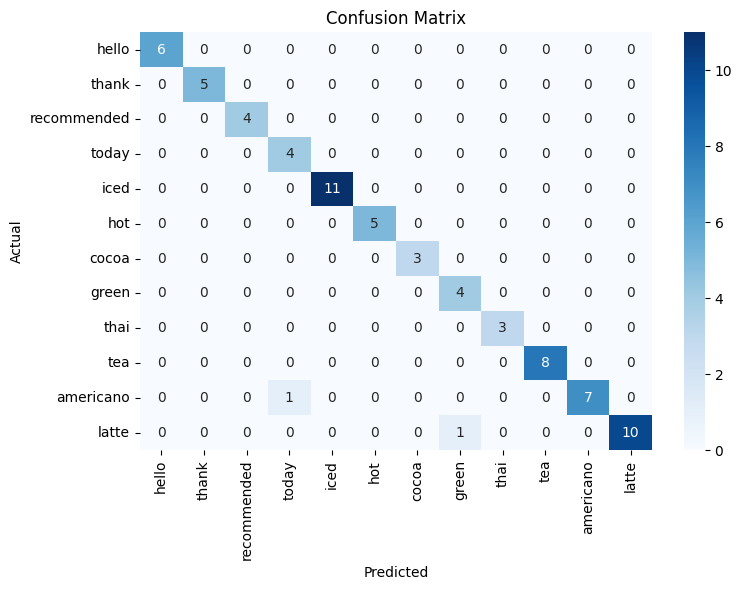

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ===== ใช้ actions เป็น label =====
labels = actions.tolist()      # แปลง np.array → list

# ----- Confusion Matrix -----
cm = confusion_matrix(ytrue, yhat, labels=range(len(labels)))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


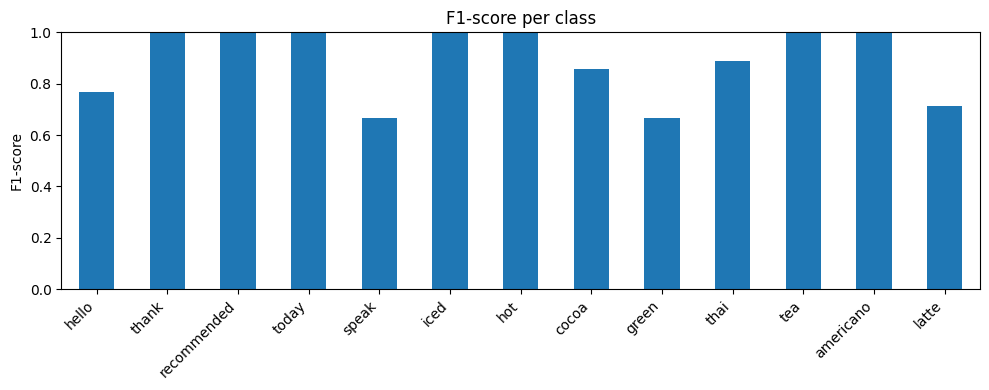

In [48]:
import pandas as pd
report = classification_report(ytrue, yhat, target_names=labels, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:-3, :]    # ตัด avg ออก

df[['f1-score']].plot(kind='bar', figsize=(10,4), legend=False)
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.title("F1-score per class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

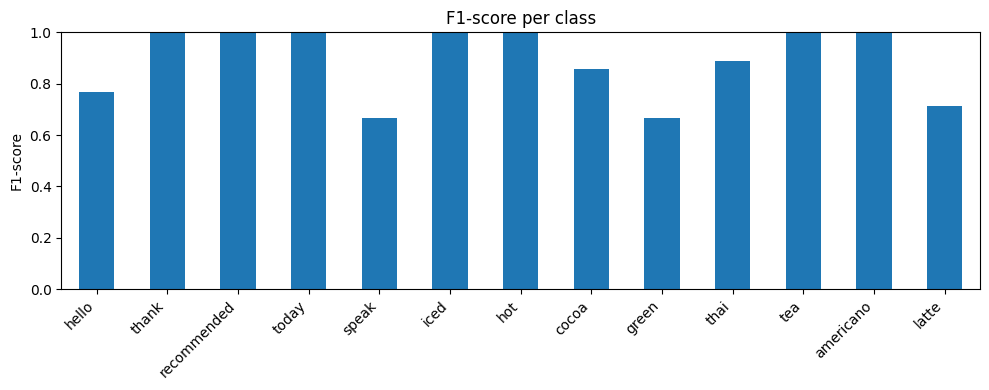

In [ ]:
import pandas as pd
report = classification_report(ytrue, yhat, target_names=labels, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:-3, :]    # ตัด avg ออก

df[['f1-score']].plot(kind='bar', figsize=(10,4), legend=False)
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.title("F1-score per class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h2>Test</h2>

In [ ]:
from scipy import stats

In [ ]:
colors = [
    (255, 99, 71),     # Tomato
    (135, 206, 235),   # Sky Blue
    (124, 252, 0),     # Lawn Green
    (255, 215, 0),     # Gold
    (186, 85, 211),    # Medium Orchid
    (60, 179, 113),    # Medium Sea Green
    (255, 140, 0),     # Dark Orange
    (30, 144, 255),    # Dodger Blue
    (220, 20, 60),     # Crimson
    (218, 165, 32),    # Goldenrod
    (255, 105, 180),   # Hot Pink
    (0, 191, 255),     # Deep Sky Blue
    (154, 205, 50),    # Yellow Green
    (123, 104, 238),   # Medium Slate Blue
    (255, 69, 0),      # Orange Red
    (0, 255, 255),     # Cyan
    (0, 250, 154),     # Medium Spring Green
    (255, 182, 193)    # Light Pink
]


In [ ]:

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [ ]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

In [ ]:
sequence.reverse()

In [ ]:
len(sequence)

In [ ]:
sequence[-30:]

In [ ]:
sequence = []
sentence = []
threshold = 0.8

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
#         sequence.insert(0,keypoints)
#         sequence = sequence[:30]
        sequence.append(keypoints)
        sequence = sequence[-25:]
        
        if len(sequence) == 25:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            
            
        #3. Viz logic
            if res[np.argmax(res)] > threshold:
                predictions_queue.append(actions[np.argmax(res)])
                
                if len(predictions_queue) > 3:
                    predictions_queue = predictions_queue[-3:]

                    if predictions_queue.count(predictions_queue[0]) == 3:
                        if len(sentence) == 0 or predictions_queue[0] != sentence[-1]:
                            sentence.append(predictions_queue[0])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
cap.release()
cv2.destroyAllWindows()